In [1]:
import sys

sys.path.insert(0, ".")
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from src.analyze import run_analysis
from src.detection_config import DetectionConfig, ScenarioConfig
from src.gaze_signal import add_gaze_speed
from src.io_utils import collect_csv_files, load_csv, normalize_time
from src.reports import build_saccade_evaluation

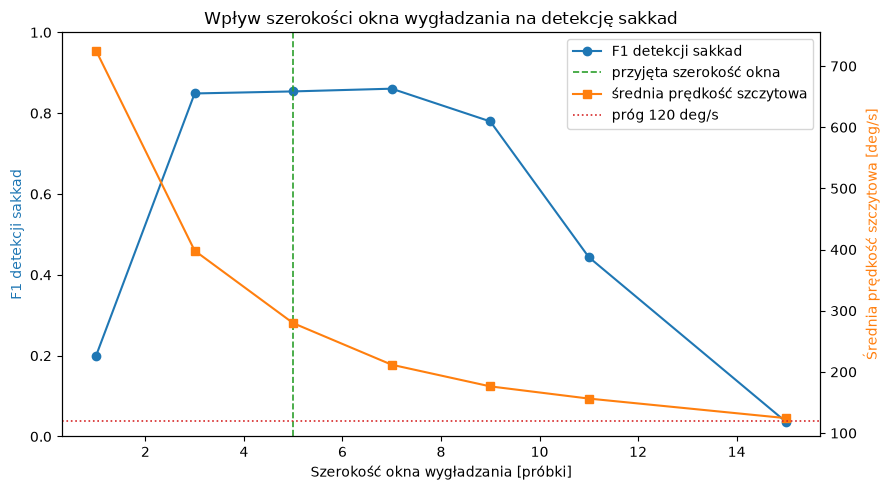

In [2]:
WINDOWS = [1, 3, 5, 7, 9, 11, 15]
saccade_files = [
    f for f in collect_csv_files(Path("data")) if f.name.startswith("SaccadeData")
]

f1_scores, peak_speeds = [], []
for window in WINDOWS:
    result = run_analysis(DetectionConfig(smoothing_window=window), ScenarioConfig())
    table = build_saccade_evaluation(result.saccade_matches, result.events)
    tp, fp, fn = table["tp"].sum(), table["fp"].sum(), table["fn"].sum()
    recall = tp / (tp + fn) if tp + fn else 0.0
    precision = tp / (tp + fp) if tp + fp else 0.0
    f1_scores.append(
        2 * recall * precision / (recall + precision) if recall + precision else 0.0
    )
    peaks = [
        add_gaze_speed(normalize_time(load_csv(f)), smoothing_window=window)[
            "gaze_speed_smooth_deg_s"
        ].max()
        for f in saccade_files
    ]
    peak_speeds.append(float(np.mean(peaks)))

fig, ax_f1 = plt.subplots(figsize=(9, 5))

ax_f1.plot(WINDOWS, f1_scores, marker="o", color="tab:blue", label="F1 detekcji sakkad")
ax_f1.axvline(
    5, color="tab:green", linestyle="--", linewidth=1.2, label="przyjęta szerokość okna"
)

ax_f1.set_xlabel("Szerokość okna wygładzania [próbki]")
ax_f1.set_ylabel("F1 detekcji sakkad", color="tab:blue")
ax_f1.set_ylim(0, 1)
ax_speed = ax_f1.twinx()
ax_speed.plot(
    WINDOWS,
    peak_speeds,
    marker="s",
    color="tab:orange",
    label="średnia prędkość szczytowa",
)
ax_speed.axhline(
    120, color="tab:red", linestyle=":", linewidth=1.2, label="próg 120 deg/s"
)

ax_speed.set_ylabel("Średnia prędkość szczytowa [deg/s]", color="tab:orange")
handles = ax_f1.get_legend_handles_labels()[0] + ax_speed.get_legend_handles_labels()[0]
labels = ax_f1.get_legend_handles_labels()[1] + ax_speed.get_legend_handles_labels()[1]
ax_f1.legend(handles, labels, loc="upper right")
ax_f1.set_title("Wpływ szerokości okna wygładzania na detekcję sakkad")
fig.tight_layout()

plt.show()